In [85]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
gender = pd.read_csv("gender_submission.csv")

test_ = pd.merge(test, gender, on="PassengerId")
data = pd.concat([train, test_], ignore_index=True)

In [86]:
print(test.shape)
print(train.shape)
print(data.shape)

(418, 11)
(891, 12)
(1309, 12)


In [87]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(2), int64(5), str(5)
memory usage: 122.8 KB


In [88]:
data.drop_duplicates() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [89]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(2), int64(5), str(5)
memory usage: 122.8 KB


In [90]:
data.isna().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [91]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [92]:
(data.isna().sum() / len(data)) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.091673
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.076394
Cabin          77.463713
Embarked        0.152788
dtype: float64

In [93]:
data[["Age", "Fare", "SibSp", "Parch"]].describe()

,Age,Fare,SibSp,Parch
count,1046.000000,1308.000000,1309.000000,1309.000000
mean,29.881138,33.295479,0.498854,0.385027
std,14.413493,51.758668,1.041658,0.865560
min,0.170000,0.000000,0.000000,0.000000
25%,21.000000,7.895800,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,39.000000,31.275000,1.000000,0.000000
max,80.000000,512.329200,8.000000,9.000000


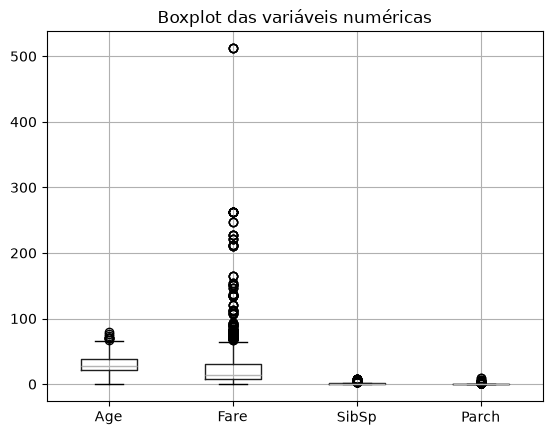

In [94]:
import matplotlib.pyplot as plt

data[["Age", "Fare", "SibSp", "Parch"]].boxplot()

plt.title("Boxplot das variáveis numéricas")
plt.show()

In [95]:
Q1 = data["Fare"].quantile(0.25)
Q3 = data["Fare"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Q1: 7.8958
Q3: 31.275
IQR: 23.379199999999997
Limite inferior: -27.172999999999995
Limite superior: 66.34379999999999


In [96]:
outliers_fare = data[(data["Fare"] < limite_inferior) |(data["Fare"] > limite_superior)]
print("Quantidade de outliers:", len(outliers_fare))

Quantidade de outliers: 171


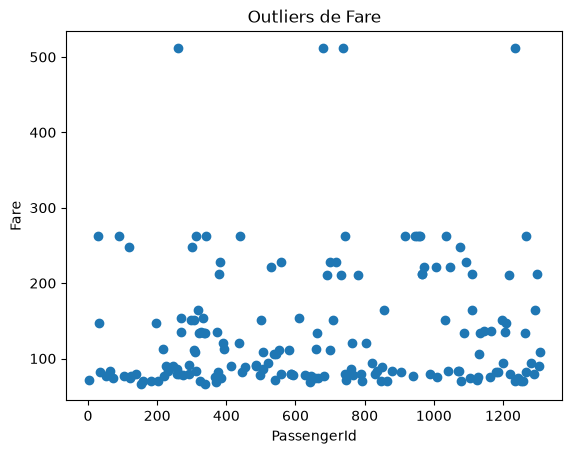

In [ ]:
plt.scatter(outliers_fare["PassengerId"], outliers_fare["Fare"])

plt.xlabel("PassengerId")
plt.ylabel("Fare")
plt.title("Outliers de Fare")
plt.show()

In [98]:
outliers_fare[outliers_fare["Fare"] > 500][["PassengerId", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Survived"]]

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Survived
258,259,1,female,35.0,0,0,512.3292,1
679,680,1,male,36.0,0,1,512.3292,1
737,738,1,male,35.0,0,0,512.3292,1
1234,1235,1,female,58.0,0,1,512.3292,1


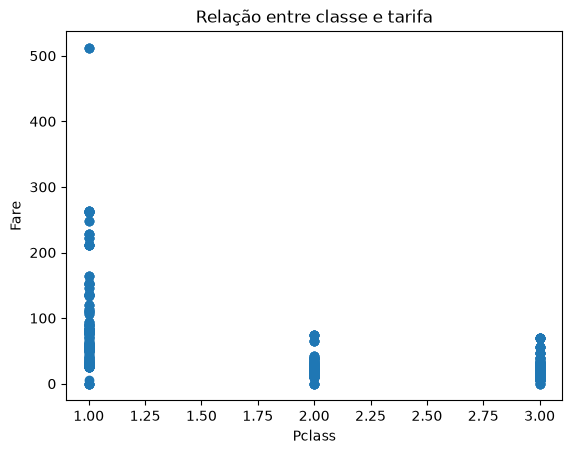

In [99]:
plt.scatter(data["Pclass"],data["Fare"])

plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.title("Relação entre classe e tarifa")
plt.show()

In [100]:
data["Fare"].isna().sum()
data[data["Fare"].isna()][["PassengerId", "Name", "Pclass", "Sex", "Age", "Fare"]]


,PassengerId,Name,Pclass,Sex,Age,Fare
1043,1044,"Storey, Mr. Thomas",3,male,60.5,NaN


In [101]:
data["Age"].describe()

count    1046.000000
mean       29.881138
std        14.413493
min         0.170000
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: Age, dtype: float64

In [102]:
Q1 = data["Age"].quantile(0.25)
Q3 = data["Age"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Q1: 21.0
Q3: 39.0
IQR: 18.0
Limite inferior: -6.0
Limite superior: 66.0


In [109]:
outliers_age = data[(data["Age"] < limite_inferior) |(data["Age"] > limite_superior)]
print("Quantidade de outliers:", len(outliers_age))

Quantidade de outliers: 9


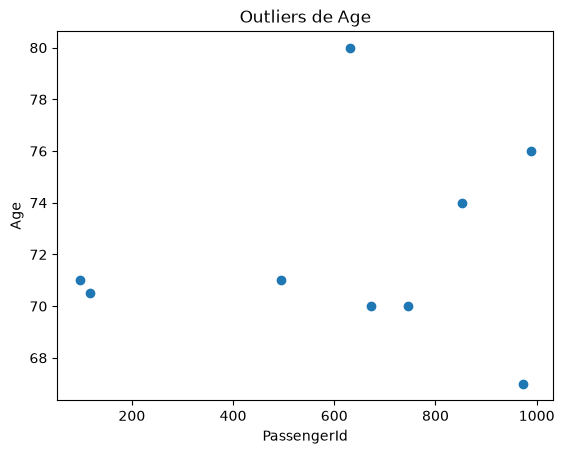

In [111]:
plt.scatter(outliers_age["PassengerId"], outliers_age["Age"])

plt.xlabel("PassengerId")
plt.ylabel("Age")
plt.title("Outliers de Age")
plt.show()

In [113]:
outliers_age[["PassengerId", "Pclass", "Sex", "Age", "Fare", "Survived"]]

,PassengerId,Pclass,Sex,Age,Fare,Survived
96,97,1,male,71.0,34.6542,0
116,117,3,male,70.5,7.7500,0
493,494,1,male,71.0,49.5042,0
630,631,1,male,80.0,30.0000,1
672,673,2,male,70.0,10.5000,0
745,746,1,male,70.0,71.0000,0
851,852,3,male,74.0,7.7750,0
972,973,1,male,67.0,221.7792,0
987,988,1,female,76.0,78.8500,1


In [114]:
data["Age"].isna().sum()

np.int64(263)

In [117]:
pd.crosstab(data["Pclass"],data["Age"].isna())

Age,False,True
Pclass,,
1,284,39
2,261,16
3,501,208


In [116]:
pd.crosstab(data["Pclass"],data["Age"].isna(),normalize="index")*100

Age,False,True
Pclass,,
1,87.925697,12.074303
2,94.223827,5.776173
3,70.662906,29.337094


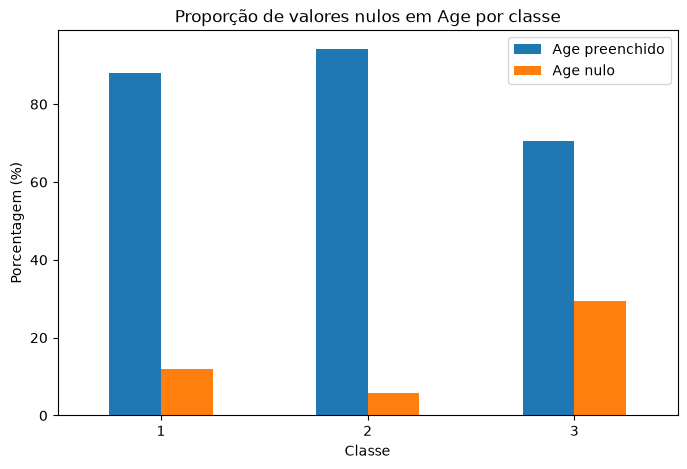

In [118]:
tabela_age_pclass = pd.crosstab(
    data["Pclass"],
    data["Age"].isna(),
    normalize="index"
) * 100

tabela_age_pclass.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Proporção de valores nulos em Age por classe")
plt.xlabel("Classe")
plt.ylabel("Porcentagem (%)")
plt.legend(["Age preenchido", "Age nulo"])
plt.xticks(rotation=0)
plt.show()